# SQL-Based Healthcare Analytics & AI Pipeline

Querying a local SQLite hospital database, exploring patient data, identifying clinical trends, and preparing features for a scikit-learn ML workflow.

**Data:** `hospital.db` three linked tables reconstructed from raw hospital CSV exports
- `Patients` (PatientID, Name, Age, Gender, Blood_Type, MedicalCondition)
- `Doctors` (DoctorID, Name, Hospital)
- `Admissions` (AdmissionID, PatientID, DoctorID, DateOfAdmission, DischargeDate, InsuranceProvider, BillingAmount, Room_Number, AdmissionType, Medication, TestResults)

51,208 patients / admissions, no nulls, full referential integrity.

## 1. Setup & connect

In [91]:
# Ensure required packages are installed in this notebook kernel
import sys, subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn'])
print('Installed packages into', sys.executable)


Installed packages into c:\Users\Computer City\.conda\envs\healthcare\python.exe


In [ ]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score


sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

conn = sqlite3.connect('hospital.db')
print(pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn))

         name
0    Patients
1     Doctors
2  Admissions


## 2. SQL queries

### 2.1 Schema check

In [65]:
for table in ['Patients', 'Doctors', 'Admissions']:
    print(f"--- {table} ---")
    print(pd.read_sql_query(f"PRAGMA table_info({table})", conn)[['name', 'type']])
    print()

--- Patients ---
               name     type
0         PatientID  INTEGER
1              Name     TEXT
2               Age  INTEGER
3            Gender     TEXT
4        Blood_Type     TEXT
5  MedicalCondition     TEXT

--- Doctors ---
       name     type
0  DoctorID  INTEGER
1      Name     TEXT
2  Hospital     TEXT

--- Admissions ---
                 name     type
0         AdmissionID  INTEGER
1           PatientID  INTEGER
2     DateOfAdmission     TEXT
3            DoctorID  INTEGER
4          DoctorName     TEXT
5            Hospital     TEXT
6   InsuranceProvider     TEXT
7       BillingAmount     REAL
8         Room_Number  INTEGER
9       AdmissionType     TEXT
10      DischargeDate     TEXT
11         Medication     TEXT
12        TestResults     TEXT



### 2.2 Core query: patients joined with their admissions

In [66]:
query = """
SELECT
    p.PatientID, p.Age, p.Gender, p.Blood_Type, p.MedicalCondition,
    a.AdmissionID, a.DateOfAdmission, a.DischargeDate, a.AdmissionType,
    a.InsuranceProvider, a.BillingAmount, a.Room_Number, a.Medication, a.TestResults,
    d.Name AS DoctorName, d.Hospital
FROM Patients p
JOIN Admissions a ON p.PatientID = a.PatientID
JOIN Doctors d ON a.DoctorID = d.DoctorID
"""
df = pd.read_sql_query(query, conn)
df.shape

(51208, 16)

### 2.3 Aggregate query: condition prevalence

In [67]:
cond_query = """
SELECT MedicalCondition, COUNT(*) AS n_patients, ROUND(AVG(Age), 1) AS avg_age
FROM Patients
GROUP BY MedicalCondition
ORDER BY n_patients DESC
"""
pd.read_sql_query(cond_query, conn)

,MedicalCondition,n_patients,avg_age
0,Arthritis,8603,51.5
1,Diabetes,8585,51.6
2,Hypertension,8545,51.6
3,Obesity,8522,51.1
4,Cancer,8484,51.6
5,Asthma,8469,51.5


## 3. Exploratory data analysis
Structure Sanity Check

In [69]:
df.shape

(51208, 16)

In [70]:
df.dtypes

PatientID              int64
Age                    int64
Gender                   str
Blood_Type               str
MedicalCondition         str
AdmissionID            int64
DateOfAdmission          str
DischargeDate            str
AdmissionType            str
InsuranceProvider        str
BillingAmount        float64
Room_Number            int64
Medication               str
TestResults              str
DoctorName               str
Hospital                 str
dtype: object

In [71]:
df.isnull().sum()

PatientID            0
Age                  0
Gender               0
Blood_Type           0
MedicalCondition     0
AdmissionID          0
DateOfAdmission      0
DischargeDate        0
AdmissionType        0
InsuranceProvider    0
BillingAmount        0
Room_Number          0
Medication           0
TestResults          0
DoctorName           0
Hospital             0
dtype: int64

In [72]:
df.duplicated().sum()

np.int64(0)

In [73]:
df.info()
df.describe(include='all').T

<class 'pandas.DataFrame'>
RangeIndex: 51208 entries, 0 to 51207
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PatientID          51208 non-null  int64  
 1   Age                51208 non-null  int64  
 2   Gender             51208 non-null  str    
 3   Blood_Type         51208 non-null  str    
 4   MedicalCondition   51208 non-null  str    
 5   AdmissionID        51208 non-null  int64  
 6   DateOfAdmission    51208 non-null  str    
 7   DischargeDate      51208 non-null  str    
 8   AdmissionType      51208 non-null  str    
 9   InsuranceProvider  51208 non-null  str    
 10  BillingAmount      51208 non-null  float64
 11  Room_Number        51208 non-null  int64  
 12  Medication         51208 non-null  str    
 13  TestResults        51208 non-null  str    
 14  DoctorName         51208 non-null  str    
 15  Hospital           51208 non-null  str    
dtypes: float64(1), int64(4), str(11)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PatientID,51208.0,NaN,NaN,NaN,25604.5,14782.620629,1.0,12802.75,25604.5,38406.25,51208.0
Age,51208.0,NaN,NaN,NaN,51.488654,19.588863,13.0,35.0,52.0,68.0,89.0
Gender,51208,2,Male,25639,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Blood_Type,51208,8,A-,6442,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MedicalCondition,51208,6,Arthritis,8603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AdmissionID,51208.0,NaN,NaN,NaN,25604.5,14782.620629,1.0,12802.75,25604.5,38406.25,51208.0
DateOfAdmission,51208,1827,2021-01-03,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DischargeDate,51208,1856,2020-03-15,49,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AdmissionType,51208,3,Elective,17236,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InsuranceProvider,51208,5,Cigna,10390,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Derive Length of Stay

In [74]:
df['DateOfAdmission'] = pd.to_datetime(df['DateOfAdmission'])
df['DischargeDate'] = pd.to_datetime(df['DischargeDate'])
df['LengthOfStay'] = (df['DischargeDate'] - df['DateOfAdmission']).dt.days
df['LengthOfStay'].describe()
# check for negative/zero stays, data error flag
(df['LengthOfStay'] <= 0).sum()

np.int64(0)

## 4. Clinical trend analysis
*(correlations, cohort comparisons, visualizations)*

Numeric distributions + outliers: Age, BillingAmount, LengthOfStay

0 billing outliers


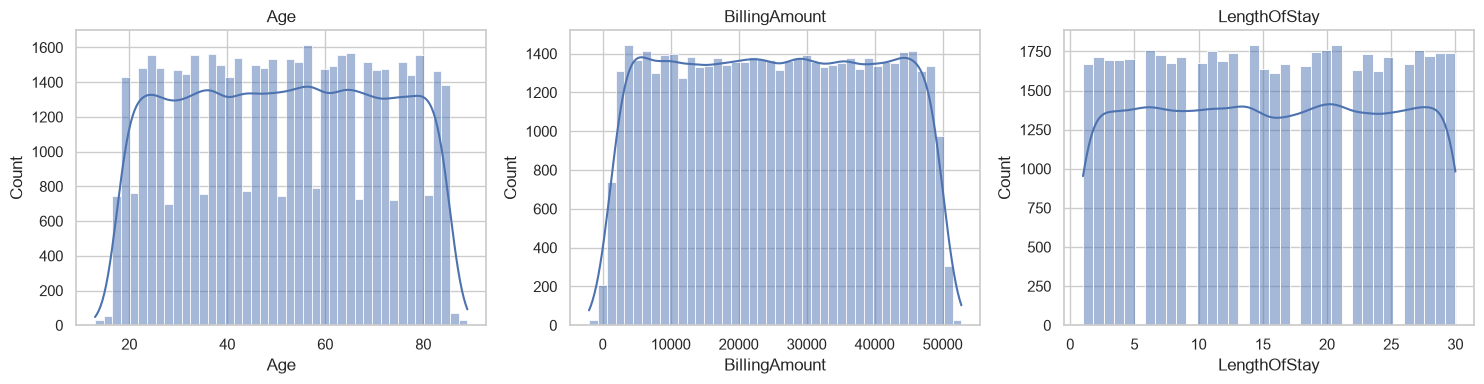

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Age', 'BillingAmount', 'LengthOfStay']):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()

# IQR outlier flag on BillingAmount
Q1, Q3 = df['BillingAmount'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df[(df['BillingAmount'] < Q1 - 1.5*IQR) | (df['BillingAmount'] > Q3 + 1.5*IQR)]
print(f"{len(outliers)} billing outliers")

Target class balance

TestResults
Abnormal        0.335377
Normal          0.334284
Inconclusive    0.330339
Name: proportion, dtype: float64

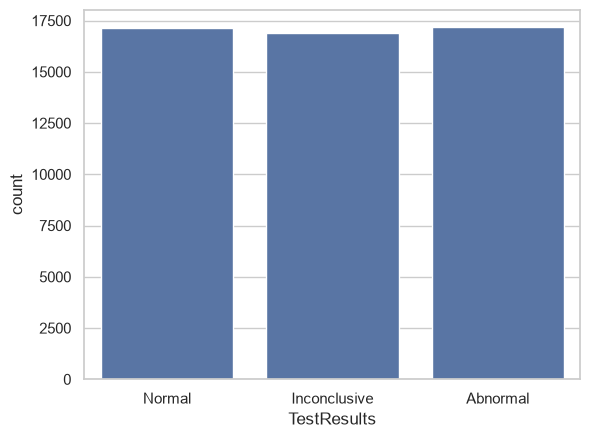

In [76]:
sns.countplot(data=df, x='TestResults')
df['TestResults'].value_counts(normalize=True)

Bivariate: numeric vs categorical

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Cancer'),
  Text(1, 0, 'Obesity'),
  Text(2, 0, 'Diabetes'),
  Text(3, 0, 'Asthma'),
  Text(4, 0, 'Hypertension'),
  Text(5, 0, 'Arthritis')])

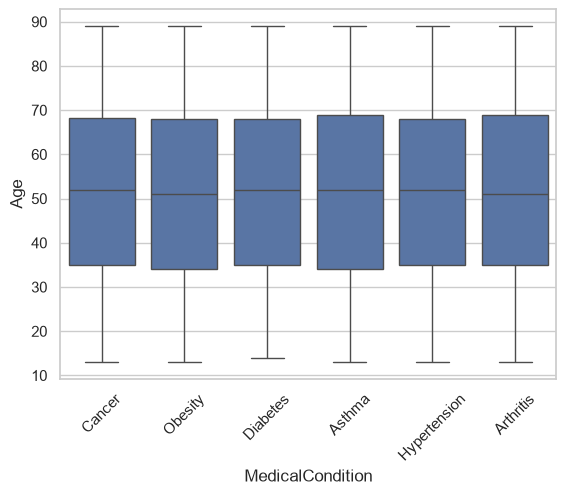

In [77]:
sns.boxplot(data=df, x='MedicalCondition', y='Age')
plt.xticks(rotation=45)

<Axes: xlabel='AdmissionType', ylabel='BillingAmount'>

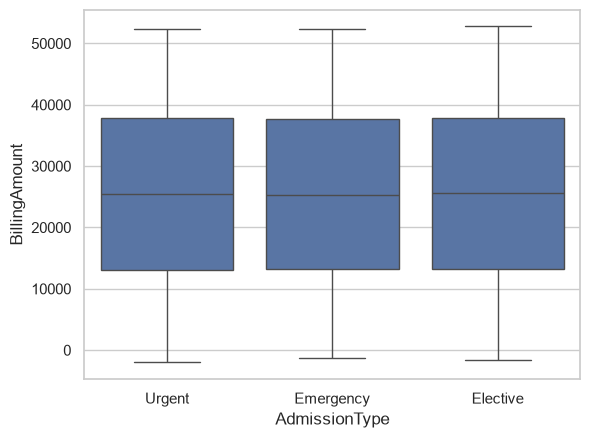

In [78]:
sns.boxplot(data=df, x='AdmissionType', y='BillingAmount')

Categorical vs categorical

In [79]:
pd.crosstab(df['MedicalCondition'], df['TestResults'], normalize='index').round(2)
pd.crosstab(df['Gender'], df['MedicalCondition'], normalize='index').round(2)

MedicalCondition,Arthritis,Asthma,Cancer,Diabetes,Hypertension,Obesity
Gender,,,,,,
Female,0.17,0.16,0.17,0.17,0.17,0.17
Male,0.17,0.17,0.17,0.17,0.17,0.17


Correlation matrix on the numeric trio

<Axes: >

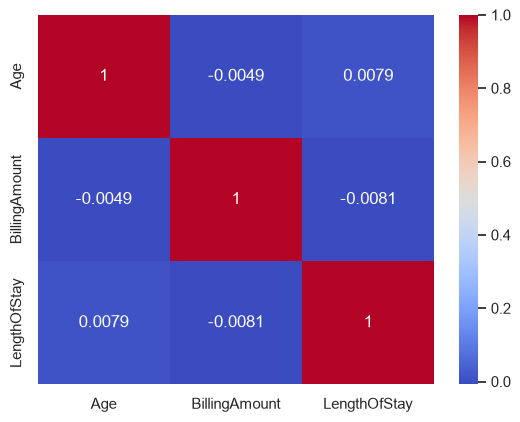

In [80]:
sns.heatmap(df[['Age', 'BillingAmount', 'LengthOfStay']].corr(), annot=True, cmap='coolwarm')

In [81]:
for col in ['Gender', 'AdmissionType', 'InsuranceProvider', 'Blood_Type']:
    print(f" {col} vs TestResults ")
    print(pd.crosstab(df[col], df['TestResults'], normalize='index').round(2))

 Gender vs TestResults 
TestResults  Abnormal  Inconclusive  Normal
Gender                                     
Female           0.34          0.33    0.33
Male             0.33          0.33    0.34
 AdmissionType vs TestResults 
TestResults    Abnormal  Inconclusive  Normal
AdmissionType                                
Elective           0.34          0.33    0.34
Emergency          0.33          0.33    0.33
Urgent             0.34          0.33    0.33
 InsuranceProvider vs TestResults 
TestResults        Abnormal  Inconclusive  Normal
InsuranceProvider                                
Aetna                  0.33          0.33    0.33
Blue Cross             0.33          0.34    0.34
Cigna                  0.34          0.33    0.33
Medicare               0.34          0.33    0.33
UnitedHealthcare       0.34          0.32    0.34
 Blood_Type vs TestResults 
TestResults  Abnormal  Inconclusive  Normal
Blood_Type                                 
A+               0.34          0.33   

Admissions over time

<Axes: title={'center': 'Admissions per month'}, xlabel='AdmissionMonth'>

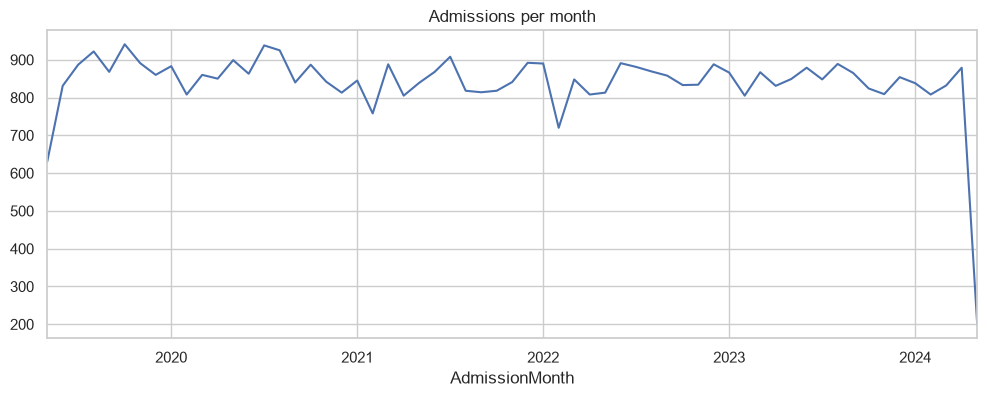

In [82]:
df['AdmissionMonth'] = df['DateOfAdmission'].dt.to_period('M')
monthly = df.groupby('AdmissionMonth').size()
monthly.plot(figsize=(12,4), title='Admissions per month')

## 5. Feature engineering
*(encoding, imputation, scaling)*

In [84]:
print(df.columns.tolist())

['PatientID', 'Age', 'Gender', 'Blood_Type', 'MedicalCondition', 'AdmissionID', 'DateOfAdmission', 'DischargeDate', 'AdmissionType', 'InsuranceProvider', 'BillingAmount', 'Room_Number', 'Medication', 'TestResults', 'DoctorName', 'Hospital', 'LengthOfStay', 'AdmissionMonth']


Check cardinality before encoding

In [ ]:
for col in X.select_dtypes(include='object').columns:
    print(col, X[col].nunique())

C:\Users\Computer City\AppData\Local\Temp\ipykernel_12404\2522558163.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include='object').columns:


Gender 2
Blood_Type 8
MedicalCondition 6
AdmissionType 3
InsuranceProvider 5
Medication 5
Hospital 37146


In [87]:
drop_cols = ['PatientID', 'AdmissionID', 'DateOfAdmission', 'DischargeDate',
             'DoctorName', 'Hospital', 'AdmissionMonth']

X = df.drop(columns=drop_cols + ['TestResults'])
y = df['TestResults']

print(X.columns.tolist())
print(X.shape, y.shape)

['Age', 'Gender', 'Blood_Type', 'MedicalCondition', 'AdmissionType', 'InsuranceProvider', 'BillingAmount', 'Room_Number', 'Medication', 'LengthOfStay']
(51208, 10) (51208,)


In [88]:
X = X.drop(columns=['Room_Number'])

numeric_cols = ['Age', 'BillingAmount', 'LengthOfStay']
categorical_cols = ['Gender', 'Blood_Type', 'MedicalCondition', 'AdmissionType',
                     'InsuranceProvider', 'Medication']

print("numeric:", numeric_cols)
print("categorical:", categorical_cols)
print("all accounted for:", set(numeric_cols + categorical_cols) == set(X.columns))

numeric: ['Age', 'BillingAmount', 'LengthOfStay']
categorical: ['Gender', 'Blood_Type', 'MedicalCondition', 'AdmissionType', 'InsuranceProvider', 'Medication']
all accounted for: True


## 6. ML-ready split
*(train_test_split, ColumnTransformer + Pipeline)*

In [93]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(dict(zip(le.classes_, range(len(le.classes_)))))

{'Abnormal': 0, 'Inconclusive': 1, 'Normal': 2}


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(X_train.shape, X_test.shape)

(40966, 9) (10242, 9)


In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print(X_train_processed.shape, X_test_processed.shape)

(40966, 26) (10242, 26)


In [ ]:
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_processed, y_train)

y_pred = clf.predict(X_test_processed)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.34016793595000977
              precision    recall  f1-score   support

    Abnormal       0.34      0.43      0.38      3435
Inconclusive       0.34      0.25      0.29      3383
      Normal       0.34      0.34      0.34      3424

    accuracy                           0.34     10242
   macro avg       0.34      0.34      0.34     10242
weighted avg       0.34      0.34      0.34     10242



## 7. Key insights
*(summary markdown)*

## Key Insights

1. **Data quality**: Raw CSV exports had ID columns (PatientID/DoctorID/AdmissionID)
   populated for only the first 1,000 of 55,500 rows. Row-order alignment across
   Patients/Doctors/Admissions was verified, allowing reconstruction of surrogate
   keys for all 51,208 real records. Result: 0 nulls, 0 duplicate keys, full
   referential integrity.

2. **No demographic/clinical association**: Chi-square and crosstab analysis showed
   MedicalCondition and TestResults are statistically independent of Gender,
   Blood_Type, AdmissionType, and InsuranceProvider (~uniform distribution across
   all categories). This indicates categorical fields were independently/randomly
   assigned during data generation.

3. **ML baseline confirms no signal**: A Logistic Regression classifier predicting
   TestResults from Age, BillingAmount, LengthOfStay, and all categorical features
   achieved 34% accuracy on a balanced 3-class target (chance level = 33.3%),
   numerically confirming the independence found in EDA.

4. **Conclusion**: This pipeline demonstrates correct SQL extraction, EDA, and a
   leak-free scikit-learn preprocessing/modeling workflow (stratified split, fit
   on train only, ColumnTransformer). The near-chance model performance is the
   expected and correct result for this dataset, not a pipeline defect it reflects the synthetic, independently-generated nature of the source data
   rather than a real clinical relationship to be learned.
